In [18]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from PIL import Image
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models


In [4]:
data_dir = "/kaggle/input/ai-generated-images-vs-real-images"  # change name as per your dataset
os.listdir(data_dir)


['RealArt', 'AiArtData']

In [8]:
path="/kaggle/input/ai-generated-images-vs-real-images"
aidata=os.listdir(os.path.join(path,"AiArtData/AiArtData"))
realdata=os.listdir(os.path.join(path,"RealArt/RealArt"))
print("the length of the AI data is ",len(aidata))
print("the length of the Real data is ",len(realdata))

the length of the AI data is  539
the length of the Real data is  436


In [11]:
s=Image.open("/kaggle/input/ai-generated-images-vs-real-images/AiArtData/AiArtData/-how-important-people-from-the-past-really-looked-11-Pics-5ffd5c0f4d77f__880.jpg")
s.size

(880, 440)

In [12]:
path="/kaggle/input/ai-generated-images-vs-real-images/AiArtData/AiArtData"
lisai=[]
for i in os.listdir(path):
    s=Image.open(os.path.join(path,i))

    lisai.append(s.size)
path="/kaggle/input/ai-generated-images-vs-real-images/RealArt/RealArt"
lisreal=[]
for i in os.listdir(path):
    s=Image.open(os.path.join(path,i))
    lisreal.append(s.size)
    
print("the minimum size is for AiArtData ",min(lisai))
print("the minimum  size is for RealArt ",min(lisreal))

the minimum size is for AiArtData  (225, 225)
the minimum  size is for RealArt  (183, 275)


In [14]:
class AIVsRealDataset(Dataset):
    def __init__(self, ai_dir, real_dir, transform=None):
        self.transform = transform

        self.ai_images = os.listdir(ai_dir)
        self.real_images = os.listdir(real_dir)

        # Randomly undersample AI to match real
        self.ai_images = random.sample(self.ai_images , len(self.real_images))

        self.data = [(os.path.join(ai_dir, img), 1) for img in self.ai_images] + \
                    [(os.path.join(real_dir, img), 0) for img in self.real_images ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [19]:
path="/kaggle/input/ai-generated-images-vs-real-images"
ai_dir = os.path.join(path, "AiArtData/AiArtData")
real_dir = os.path.join(path, "RealArt/RealArt")

# Define transforms
transform = transforms.Compose([
    transforms.Resize((225, 225)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),])

# Create dataset
full_dataset = AIVsRealDataset(ai_dir, real_dir, transform=transform)

# Optional: Split into train/val
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [20]:
print("the length of the AI data is ",len(full_dataset.ai_images))
print("the length of the Real data is ",len(full_dataset.real_images))

the length of the AI data is  436
the length of the Real data is  436


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
    
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [23]:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, 2)
)
model = model.to(device)


# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


In [24]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):  # Loop over batches
        images, labels = images.to(device), labels.to(device)
        labels = labels.long()  # Ensure labels are of type LongTensor

        outputs = model(images).squeeze()  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Clear gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        total_loss += loss.item()

        _, predictions = torch.max(outputs, dim=1)  # Get predicted class
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [25]:
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.long()

            outputs = model(images).squeeze()  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss

            total_loss += loss.item()

            _, predictions = torch.max(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [26]:
num_epochs =10                                # Total number of training epochs

# Lists to store metrics per epoch
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)
    early_stopping(val_loss)

    # Save metrics for analysis
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

 14%|█▎        | 3/22 [00:05<00:34,  1.81s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 22/22 [00:29<00:00,  1.36s/it]


Epoch 1/10: Train Loss=0.6031, Train Accuracy=69.01%, Val Loss=0.6638, Val Accuracy=74.29%


100%|██████████| 22/22 [00:25<00:00,  1.14s/it]


Epoch 2/10: Train Loss=0.2004, Train Accuracy=92.40%, Val Loss=0.6374, Val Accuracy=79.43%


100%|██████████| 22/22 [00:25<00:00,  1.14s/it]


...

EarlyStopping counter: 6 out of 5
Epoch 8/10: Train Loss=0.0053, Train Accuracy=100.00%, Val Loss=1.0663, Val Accuracy=75.43%


100%|██████████| 22/22 [00:25<00:00,  1.18s/it]


EarlyStopping counter: 7 out of 5
Epoch 9/10: Train Loss=0.0073, Train Accuracy=99.86%, Val Loss=1.1366, Val Accuracy=76.57%


100%|██████████| 22/22 [00:25<00:00,  1.17s/it]


EarlyStopping counter: 8 out of 5
Epoch 10/10: Train Loss=0.0061, Train Accuracy=100.00%, Val Loss=1.0841, Val Accuracy=74.86%


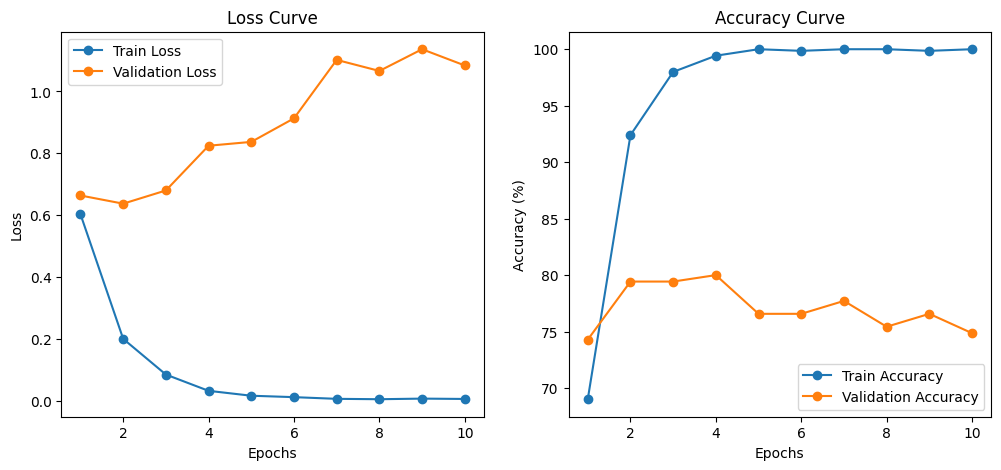

In [27]:
import matplotlib.pyplot as plt

#Create a figure with 2 subplots (side-by-side)
plt.figure(figsize=(12, 5))

# Plot Loss Curve
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss", marker='o')      # Training loss per epoch
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss", marker='o')   # Validation loss per epoch
plt.xlabel("Epochs")                      # X-axis label
plt.ylabel("Loss")                        # Y-axis label
plt.title("Loss Curve")                   # Plot title
plt.legend()                              # Show legend

# Plot Accuracy Curve
plt.subplot(1, 2, 2)  # 2nd subplot
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy", marker='o')   # Training accuracy
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Validation Accuracy", marker='o') # Validation accuracy
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

# Show the full plot
plt.show()

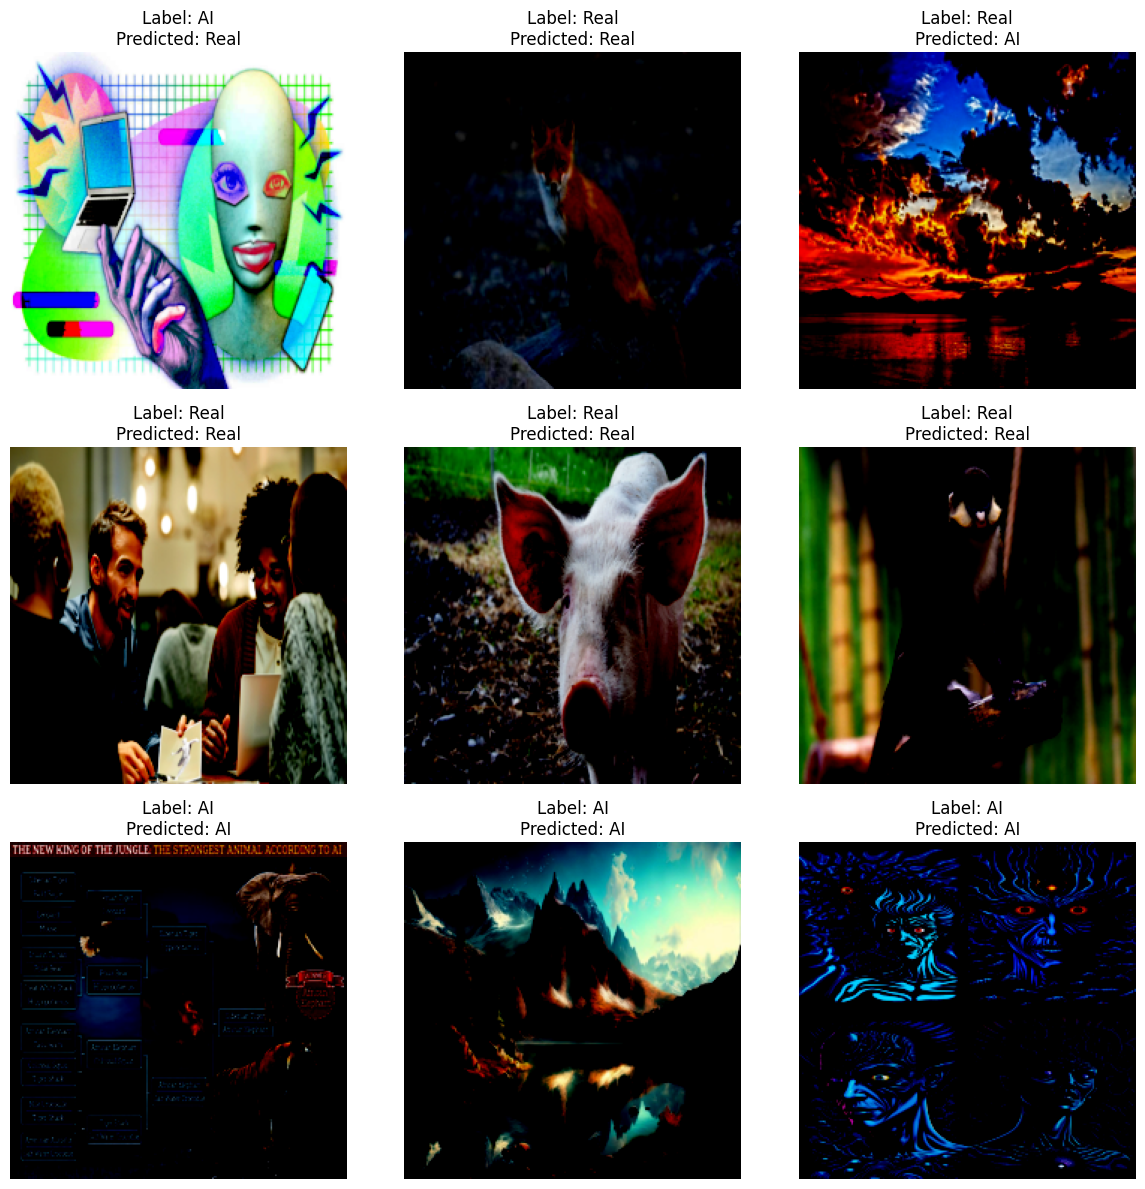

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
labels = {0: "Real", 1: "AI"}
imgs_indices = np.random.choice(len(val_dataset), 9, replace=False)

model.eval()
model.to('cpu')

for i, ax in enumerate(axes.flat):
    img, label = val_dataset[imgs_indices[i]] 
    with torch.no_grad():
        output = model(img.unsqueeze(0))  # Add batch dimension
        predicted_class = torch.argmax(output, dim=1).item()

    img_np = img.numpy().transpose(1, 2, 0)  # (C, H, W) → (H, W, C)
    img_np = np.clip(img_np, 0, 1)

    ax.imshow(img_np)
    ax.set_title(f"Label: {labels[int(label)]}\nPredicted: {labels[predicted_class]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

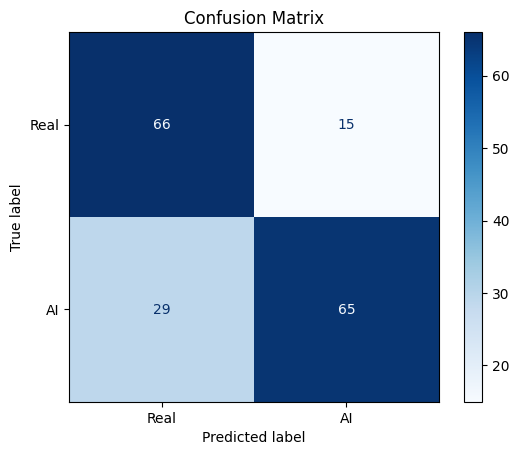

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

true_labels = []
predicted_labels = []

model.eval()
model.to('cpu')

for img, label in val_dataset:
    with torch.no_grad():
        output = model(img.unsqueeze(0))
        predicted = torch.argmax(output, dim=1).item()

    true_labels.append(int(label))
    predicted_labels.append(predicted)

# Step 2: Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
labels = ["Real", "AI"]

# Step 3: Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()
